### 1D 混沌系统
$f(x) = |\sin((5+3\mu)*(1-vx\sin(15\pi x*(1-x)))|$

Estimated Lyapunov exponent = 3.840236930997154


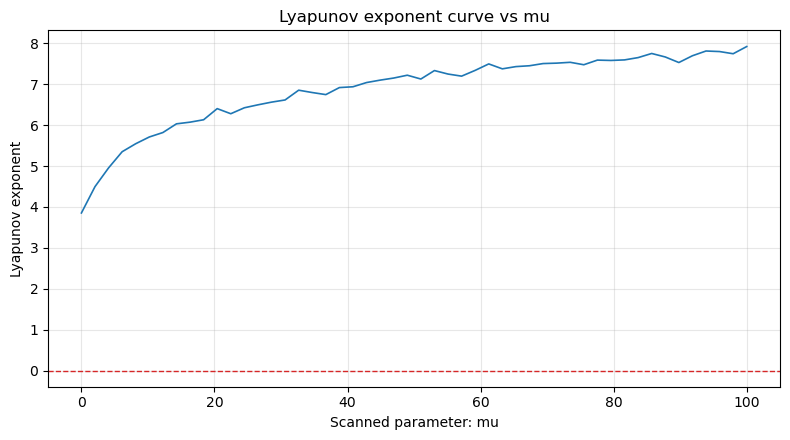

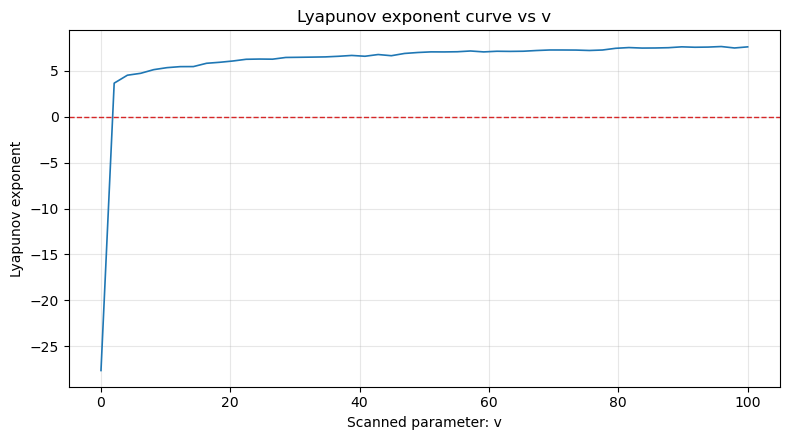

In [5]:
"""One-dimensional chaotic system based on a sinusoidal-cosine map.

Given formula:
f(x) = |sin((A + B*mu) * (4/(a-0.5) * cos(pi*x)))|
"""

from __future__ import annotations

from collections.abc import Callable
from typing import Union

import numpy as np
import sympy as sp


Number = Union[int, float, np.number]
ArrayInput = Union[Number, np.ndarray]
MapExprBuilder = Callable[[sp.Symbol, dict[str, sp.Symbol]], sp.Expr]


class Chaotic1DSystem:
	"""A configurable 1D chaotic map system with automatic differentiation."""

	def __init__(
		self,
		params: dict[str, float],
		map_expr_builder: MapExprBuilder | None = None,
	) -> None:
		if not isinstance(params, dict) or len(params) == 0:
			raise ValueError("'params' must be a non-empty dictionary of parameter values.")

		self.params = {name: float(value) for name, value in params.items()}
		self._param_order = list(self.params.keys())
		self._map_expr_builder = map_expr_builder or self._default_map_expr
		self._uses_default_map = map_expr_builder is None

		self._compile_symbolic_system()

	@staticmethod
	def _default_map_expr(x: sp.Symbol, p: dict[str, sp.Symbol]) -> sp.Expr:
		required = {"A", "B", "mu", "a"}
		missing = required - set(p)
		if missing:
			raise ValueError(f"Default map requires params keys: {sorted(required)}. Missing: {sorted(missing)}")

		return sp.Abs(
			sp.sin(
				(p["A"] + p["B"] * p["mu"]) * ((sp.Integer(4) / (p["a"] - sp.Rational(1, 2))) * sp.cos(sp.pi * x))
			)
		)

	def _compile_symbolic_system(self) -> None:
		self._x_symbol = sp.Symbol("x", real=True)
		self._param_symbols = {name: sp.Symbol(name, real=True) for name in self._param_order}

		expr = self._map_expr_builder(self._x_symbol, self._param_symbols)
		if not isinstance(expr, sp.Expr):
			raise TypeError("'map_expr_builder' must return a SymPy expression.")

		expected_symbols = {self._x_symbol, *self._param_symbols.values()}
		extra_symbols = expr.free_symbols - expected_symbols
		if extra_symbols:
			raise ValueError(f"Expression has unknown symbols: {sorted(str(s) for s in extra_symbols)}")

		self._map_expr = expr
		self._diff_expr = sp.diff(self._map_expr, self._x_symbol)

		arg_symbols = [self._x_symbol] + [self._param_symbols[name] for name in self._param_order]
		self._map_callable = sp.lambdify(arg_symbols, self._map_expr, modules="numpy")
		self._diff_callable = sp.lambdify(arg_symbols, self._diff_expr, modules="numpy")

	def set_map_relation(self, map_expr_builder: MapExprBuilder, params: dict[str, float] | None = None) -> None:
		"""Replace f(x) relation and optionally refresh parameters."""
		if params is not None:
			if not isinstance(params, dict) or len(params) == 0:
				raise ValueError("'params' must be a non-empty dictionary of parameter values.")
			self.params = {name: float(value) for name, value in params.items()}
			self._param_order = list(self.params.keys())

		self._map_expr_builder = map_expr_builder
		self._uses_default_map = False
		self._compile_symbolic_system()

	def _evaluate_map(self, x: ArrayInput) -> np.ndarray:
		param_values = [self.params[name] for name in self._param_order]
		return np.asarray(self._map_callable(x, *param_values), dtype=float)

	def _evaluate_diff(self, x: Number) -> float:
		param_values = [self.params[name] for name in self._param_order]
		derivative = self._diff_callable(float(x), *param_values)
		return float(np.abs(derivative))

	def _validate_default_singularity(self) -> None:
		if self._uses_default_map and np.isclose(self.params.get("a", np.nan), 0.5):
			raise ValueError("Parameter 'a' cannot be 0.5 for the default map because of division by zero.")

	def map_value(self, x: ArrayInput) -> Union[float, np.ndarray]:
		"""Evaluate one iteration of the chaotic map.

		Args:
			x: Scalar or NumPy array input.

		Returns:
			Scalar float for scalar input, ndarray for array input.
		"""
		self._validate_default_singularity()

		x_array = np.asarray(x, dtype=float)
		mapped = self._evaluate_map(x_array)

		if np.isscalar(x) or x_array.ndim == 0:
			return float(mapped)
		return mapped

	def _abs_derivative(self, x: Number) -> float:
		"""Return |f'(x)| from symbolic auto-differentiation."""
		self._validate_default_singularity()
		return self._evaluate_diff(x)

	def generate_sequence(self, x0: Number, n: int, include_x0: bool = False) -> np.ndarray:
		"""Generate a chaotic sequence by iterative mapping.

		Args:
			x0: Initial scalar value.
			n: Number of iterations to generate.
			include_x0: If True, prepend x0 to the output sequence.

		Returns:
			NumPy array of generated values.
		"""
		if not isinstance(n, int):
			raise TypeError("'n' must be an integer.")
		if n <= 0:
			raise ValueError("'n' must be a positive integer.")

		x0_array = np.asarray(x0)
		if x0_array.ndim != 0:
			raise TypeError("'x0' must be a scalar value.")

		values = []
		current = float(x0)

		if include_x0:
			values.append(current)

		for _ in range(n):
			current = float(self.map_value(current))
			values.append(current)

		return np.asarray(values, dtype=float)

	def lyapunov_exponent(self, x0: Number, n: int, discard: int = 100, epsilon: float = 1e-12) -> float:
		"""Estimate Lyapunov exponent for the map orbit starting from x0.

		Lyapunov exponent is estimated by:
		lambda ~= (1/n) * sum(log(|f'(x_i)|)), i=1..n
		after discarding initial transient iterations.

		Args:
			x0: Initial scalar value.
			n: Number of post-transient iterations used for estimation.
			discard: Number of initial transient iterations to skip.
			epsilon: Lower bound for |f'(x)| before log, for numerical stability.

		Returns:
			Estimated Lyapunov exponent as float.
		"""
		if not isinstance(n, int):
			raise TypeError("'n' must be an integer.")
		if not isinstance(discard, int):
			raise TypeError("'discard' must be an integer.")
		if n <= 0:
			raise ValueError("'n' must be a positive integer.")
		if discard < 0:
			raise ValueError("'discard' must be a non-negative integer.")
		if epsilon <= 0:
			raise ValueError("'epsilon' must be positive.")

		x0_array = np.asarray(x0)
		if x0_array.ndim != 0:
			raise TypeError("'x0' must be a scalar value.")

		self._validate_default_singularity()

		current = float(x0)
		total_steps = discard + n
		log_sum = 0.0

		for step in range(total_steps):
			if step >= discard:
				abs_derivative = self._abs_derivative(current)
				log_sum += float(np.log(max(abs_derivative, epsilon)))
			current = float(self.map_value(current))

		return log_sum / float(n)

	def lyapunov_parameter_scan(
		self,
		parameter: str,
		values: np.ndarray,
		x0: Number,
		n: int,
		discard: int = 100,
		epsilon: float = 1e-12,
	) -> tuple[np.ndarray, np.ndarray]:
		"""Scan one parameter in params and return Lyapunov curve data.

		Args:
			parameter: Key in self.params to scan.
			values: 1D NumPy array of parameter values to scan.
			x0: Initial scalar value for orbit.
			n: Number of post-transient iterations per scan point.
			discard: Number of transient iterations to skip per point.
			epsilon: Lower bound for |f'(x)| before log.

		Returns:
			A tuple (param_values, lyapunov_values), both 1D arrays.
		"""
		if parameter not in self.params:
			raise ValueError(f"Unknown parameter '{parameter}'. Available keys: {self._param_order}")

		param_values = np.asarray(values, dtype=float)
		if param_values.ndim != 1:
			raise TypeError("'values' must be a 1D array.")
		if param_values.size == 0:
			raise ValueError("'values' must not be empty.")

		original_value = float(self.params[parameter])
		lyap_values = np.empty_like(param_values, dtype=float)

		try:
			for idx, param in enumerate(param_values):
				param_float = float(param)
				self.params[parameter] = param_float
				try:
					lyap_values[idx] = self.lyapunov_exponent(
						x0=x0,
						n=n,
						discard=discard,
						epsilon=epsilon,
					)
				except (ValueError, ZeroDivisionError, FloatingPointError, OverflowError):
					lyap_values[idx] = np.nan
		finally:
			self.params[parameter] = original_value

		#sym:lyapunov_parameter_scan
		try:
			import matplotlib.pyplot as plt
		except ImportError as exc:
			raise ImportError("matplotlib is required for plotting. Install it via: pip install matplotlib") from exc

		plt.figure(figsize=(8, 4.5))
		plt.plot(param_values, lyap_values, color="tab:blue", linewidth=1.2)
		plt.axhline(0.0, color="tab:red", linestyle="--", linewidth=1.0)
		plt.xlabel(f"Scanned parameter: {parameter}")
		plt.ylabel("Lyapunov exponent")
		plt.title(f"Lyapunov exponent curve vs {parameter}")
		plt.grid(True, alpha=0.3)
		plt.tight_layout()
		plt.show()

		return param_values, lyap_values


if __name__ == "__main__":
    
	def custom_map(x, p) -> sp.Expr:
		k = p["A"]+p["B"]*p["mu"]
		c = 4/(p["a"]-0.5) * sp.cos(sp.pi*x)
		c2 = 1 - p["v"]* x * sp.sin(p["C"]*sp.pi*x*(1-x))
		return sp.Abs(sp.sin(k*c2))

	system = Chaotic1DSystem(params={"A": 5, "B": 3, "mu": 0.8, "a": 1.2,"C":15,"v":3},map_expr_builder=custom_map)
	lyap = system.lyapunov_exponent(x0=0.123456, n=1000, discard=500)
	print("Estimated Lyapunov exponent =", lyap)

	mu_values = np.linspace(0, 100, 50)
	scan_mu, scan_lyap = system.lyapunov_parameter_scan(
		parameter="mu",
		values=mu_values,
		x0=0.5,
		n=300,
		discard=150,
	)
	v_values = np.linspace(0,100,50)
	scan_a ,scan_lyap = system.lyapunov_parameter_scan("v",v_values,0.5,300,150)



### 利用该一维混沌映射，构建一个MyCML


\begin{aligned}
f(x) &= |\sin((5+3\mu)(1-(ax\sin{(15\pi x(1-x))})))|,\\[2mm]
g(z) &= |\sin((5+3\lambda)(1-(bz\sin{(15\pi z(1-z))})))|,\\[2mm]
\begin{bmatrix}
p\\q\end{bmatrix}
&=
\begin{bmatrix}
1 & \xi\\\eta & \xi\eta+1\end{bmatrix}
\begin{bmatrix}
i\\i\end{bmatrix}
\pmod{L},\\[2mm]
x_{n+1}(i) &= (1-g(z))f[x_n(i)]
+ \frac{g(z)}{2}\{f[x_n(p)] + f[x_n(q)]\} \pmod{1},\\[2mm]
&\quad (\text{if } \xi=0,\ \eta=L;\ \text{if } \eta=0,\ \xi=L).
\end{aligned}





In [ ]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import sympy as sp
from rich.progress import BarColumn, Progress, TaskProgressColumn, TextColumn, TimeElapsedColumn, TimeRemainingColumn


class CMLSystem:
    """Coupled map lattice system based on the provided research formula."""

    def __init__(self, L: int, params: dict[str, float]) -> None:
        self.L = int(L)

        self.mu = float(params["mu"])
        self.lam = float(params["lam"])
        self.a = float(params["a"])
        self.b = float(params["b"])
        self.xi = int(params["xi"])
        self.eta = int(params["eta"])

        # Follow the note in your formula description.
        if self.xi == 0:
            self.eta = self.L
        if self.eta == 0:
            self.xi = self.L

        self._build_symbolic_functions()
        self._build_neighbor_indices()

    def _build_symbolic_functions(self) -> None:
        x = sp.Symbol("x", real=True)
        mu = sp.Symbol("mu", real=True)
        lam = sp.Symbol("lam", real=True)
        a = sp.Symbol("a", real=True)
        b = sp.Symbol("b", real=True)

        f_expr = sp.Abs(sp.sin((5 + 3 * mu) * (1 - (a * x * sp.sin(15 * sp.pi * x * (1 - x))))))
        g_expr = sp.Abs(sp.sin((5 + 3 * lam) * (1 - (b * x * sp.sin(15 * sp.pi * x * (1 - x))))))

        f_diff_expr = sp.diff(f_expr, x)

        self._f = sp.lambdify((x, mu, a), f_expr, modules="numpy")
        self._g = sp.lambdify((x, lam, b), g_expr, modules="numpy")
        self._f_diff = sp.lambdify((x, mu, a), f_diff_expr, modules="numpy")

    def _build_neighbor_indices(self) -> None:
        i = np.arange(self.L, dtype=int)
        p = ((1 + self.xi) * i) % self.L
        q = ((self.eta + self.xi * self.eta + 1) * i) % self.L
        self._p_idx = p.astype(int)
        self._q_idx = q.astype(int)

    def f(self, x: np.ndarray | float) -> np.ndarray | float:
        return self._f(x, self.mu, self.a)

    def g(self, z: float) -> float:
        return float(self._g(z, self.lam, self.b))

    def _f_prime(self, x: np.ndarray) -> np.ndarray:
        return np.asarray(self._f_diff(x, self.mu, self.a), dtype=float)

    def step(self, x: np.ndarray, z: float) -> tuple[np.ndarray, float]:
        x = np.asarray(x, dtype=float)
        g_z = self.g(z)
        fx = np.asarray(self.f(x), dtype=float)

        x_next = (1.0 - g_z) * fx + (g_z / 2.0) * (fx[self._p_idx] + fx[self._q_idx])
        x_next = np.mod(x_next, 1.0)

        z_next = np.mod(g_z, 1.0)
        return x_next, float(z_next)

    def iterate(self, x0: np.ndarray, z0: float, steps: int, discard: int = 0) -> tuple[np.ndarray, float]:
        x = np.asarray(x0, dtype=float).copy()
        z = float(z0)

        for _ in range(discard + steps):
            x, z = self.step(x, z)

        return x, z

    def _jacobian_x(self, x: np.ndarray, z: float) -> np.ndarray:
        g_z = self.g(z)
        fp = self._f_prime(x)

        J = np.zeros((self.L, self.L), dtype=float)
        coef_center = 1.0 - g_z
        coef_neighbor = g_z / 2.0

        # method1: loop
        for i in range(self.L):
            J[i, i] += coef_center * fp[i]
            p = self._p_idx[i]
            q = self._q_idx[i]
            J[i, p] += coef_neighbor * fp[p]
            J[i, q] += coef_neighbor * fp[q]
        # method2: vectorized (but may be less clear)
#         idx = np.arange(self.L, dtype=int)
#         J = np.zeros((self.L, self.L), dtype=float)
# 
#         np.add.at(J, (idx, idx), coef_center * fp)
#         np.add.at(J, (idx, self._p_idx), coef_neighbor * fp[self._p_idx])
#         np.add.at(J, (idx, self._q_idx), coef_neighbor * fp[self._q_idx])
   

        return J

    def lyapunov_spectrum(
        self,
        x0: np.ndarray,
        z0: float,
        n: int,
        discard: int = 100,
        epsilon: float = 1e-12,
    ) -> np.ndarray:
        """Return full Lyapunov spectrum (length L) in descending order."""
        x = np.asarray(x0, dtype=float).copy()
        z = float(z0)

        Q = np.eye(self.L, dtype=float)
        log_sum = np.zeros(self.L, dtype=float)

        total_steps = discard + n
        for step_idx in range(total_steps):
            J = self._jacobian_x(x, z)
            Z = J @ Q
            Q, R = np.linalg.qr(Z)

            if step_idx >= discard:
                d = np.abs(np.diag(R))
                log_sum += np.log(d + epsilon)

            x, z = self.step(x, z)

        spectrum = log_sum / float(n)
        return np.sort(spectrum)[::-1]

    @staticmethod
    def ked_keb(spectrum: np.ndarray) -> tuple[float, float]:
        """Compute KED and KEB from one Lyapunov spectrum vector.

        Args:
            spectrum: 1D array, e.g. spectra[i, j, :] with length L.

        Returns:
            (ked, keb)
         """
        lam = np.asarray(spectrum, dtype=float).reshape(-1)
        positive = lam[lam > 0.0]
        N = lam.size

        ked = float(np.sum(positive) / N)
        keb = float(positive.size / N)
        return ked, keb

    def _set_param_value(self, name: str, value: float) -> None:
        if name in ("xi", "eta"):
            setattr(self, name, int(value))
        else:
            setattr(self, name, float(value))

    def _sync_index_rule(self) -> None:
        if self.xi == 0:
            self.eta = self.L
        if self.eta == 0:
            self.xi = self.L
        self._build_neighbor_indices()

    def lyap_scan(
        self,
        param1: str,
        values1: np.ndarray,
        param2: str,
        values2: np.ndarray,
        x0: np.ndarray,
        z0: float,
        n: int,
        discard: int = 100,
        epsilon: float = 1e-12,
        save_path: str = "mywork/output/cml_lyapunov_scan.npz",
    ) -> np.ndarray:
        """Scan two parameters and save all Lyapunov spectra for every combination.

        Returns:
            spectra: shape = (len(values1), len(values2), L)
         """
        path = Path(save_path)
        path.parent.mkdir(parents=True, exist_ok=True)

        if path.exists():
            print(f"[scan] File already exists: {path}")
            while True:
                choice = input("Choose action: [s]kip / [d]elete and rescan: ").strip().lower()
                if choice in ("s", "skip"):
                    print("[scan] Skip current scan. Loading existing spectra from file.")
                    with np.load(path) as existing:
                        if "spectra" not in existing:
                            raise KeyError(f"'spectra' not found in existing file: {path}")
                        return np.asarray(existing["spectra"], dtype=float)
                if choice in ("d", "delete"):
                    path.unlink()
                    print("[scan] Existing file deleted. Start new scan.")
                    break
                print("Invalid input. Please type 's' or 'd'.")

        v1 = np.asarray(values1, dtype=float)
        v2 = np.asarray(values2, dtype=float)
        spectra = np.empty((v1.size, v2.size, self.L), dtype=float)

        original = {
            "mu": self.mu,
            "lam": self.lam,
            "a": self.a,
            "b": self.b,
            "xi": self.xi,
            "eta": self.eta,
        }
        ked = np.empty((v1.size, v2.size), dtype=float)
        keb = np.empty((v1.size, v2.size), dtype=float)

        total = int(v1.size * v2.size)
        with Progress(
            TextColumn("[bold cyan]{task.description}"),
            BarColumn(),
            TaskProgressColumn(),
            TimeElapsedColumn(),
            TimeRemainingColumn(),
        ) as progress:
            task = progress.add_task(f"Scanning {param1} x {param2}", total=total)
            for i, p1 in enumerate(v1):
                for j, p2 in enumerate(v2):
                    self._set_param_value(param1, float(p1))
                    self._set_param_value(param2, float(p2))
                    self._sync_index_rule()
                    spectra[i, j, :] = self.lyapunov_spectrum(
                        x0=x0,
                        z0=z0,
                        n=n,
                        discard=discard,
                        epsilon=epsilon,
                    )
                    ked_, keb_ = self.ked_keb(spectra[i, j, :])
                    ked[i, j] = ked_
                    keb[i, j] = keb_
                    progress.update(task, advance=1)


        for key, value in original.items():
            setattr(self, key, value)
        self._sync_index_rule()

        np.savez_compressed(
            path,
            spectra=spectra,
            ked=ked,
            keb=keb,
               param1_name=param1,
            param2_name=param2,
            param1_values=v1,
            param2_values=v2,
        )
        return spectra

    def plot_ked_keb(self, data_path: str) -> None:

        """Load saved scan data and plot KED/KEB 3D surfaces."""
        import matplotlib.pyplot as plt

        data = np.load(data_path)
        ked = np.asarray(data["ked"], dtype=float)
        keb = np.asarray(data["keb"], dtype=float)
        v1 = np.asarray(data["param1_values"], dtype=float)
        v2 = np.asarray(data["param2_values"], dtype=float)

        p1_name = str(data["param1_name"])
        p2_name = str(data["param2_name"])

        X, Y = np.meshgrid(v1, v2, indexing="ij")
        ked_max = float(np.nanmax(ked)) if ked.size else 0.0
        if not np.isfinite(ked_max) or ked_max <= 0.0:
            ked_max = 1e-12

        fig = plt.figure(figsize=(14, 6))

        ax1 = fig.add_subplot(1, 2, 1, projection="3d")
        surf1 = ax1.plot_surface(X, Y, ked, cmap="viridis", linewidth=0, antialiased=True)
        ax1.set_title("KED 3D Surface")
        ax1.set_xlabel(p1_name)
        ax1.set_ylabel(p2_name)
        ax1.set_zlabel("KED")
        ax1.set_zlim(0.0, ked_max)
        fig.colorbar(surf1, ax=ax1, shrink=0.65, pad=0.08)

        ax2 = fig.add_subplot(1, 2, 2, projection="3d")
        surf2 = ax2.plot_surface(X, Y, keb, cmap="plasma", linewidth=0, antialiased=True)
        ax2.set_title("KEB 3D Surface")
        ax2.set_xlabel(p1_name)
        ax2.set_ylabel(p2_name)
        ax2.set_zlabel("KEB")
        ax2.set_zlim(0.0, 1.2)
        fig.colorbar(surf2, ax=ax2, shrink=0.65, pad=0.08)

        plt.tight_layout()
        plt.show()


    def generate_random_bits_file(
    self,
    n_bits: int,
    save_path: str = "mywork/output/cml_random.bin",
    x0: np.ndarray | None = None,
    z0: float | None = None,
    warmup: int = 200,
    threshold: float = 0.5,
    channel_index: int = 0,
    bitorder: str = "little",
    seed: int | None = None,
) -> Path:


        path = Path(save_path)
        path.parent.mkdir(parents=True, exist_ok=True)

        if path.exists():
            print(f"[prng] File already exists: {path}")
            while True:
                choice = input("Choose action: [s]kip / [d]elete and regenerate: ").strip().lower()
                if choice in ("s", "skip"):
                    print("[prng] Skip generation and keep existing file.")
                    return path
                if choice in ("d", "delete"):
                    path.unlink()
                    print("[prng] Existing file deleted. Start generating.")
                    break
                print("Invalid input. Please type 's' or 'd'.")

        rng = np.random.default_rng(seed)

        if x0 is None or z0 is None:
            raise ValueError("Both x0 and z0 must be provided as initial conditions for the CML system.")
        # Burn-in to reduce initial transient effect.
        for _ in range(max(0, int(warmup))):
            x, z = self.step(x, z)

        idx = int(channel_index) % self.L
        bits = np.empty(n_bits, dtype=np.uint8)

        for i in range(n_bits):
            x, z = self.step(x, z)
            bits[i] = 1 if x[idx] >= threshold else 0

        # Pack bits to bytes and write binary file.
        pad = (-n_bits) % 8
        if pad:
            bits = np.pad(bits, (0, pad), mode="constant", constant_values=0)

        packed = np.packbits(bits, bitorder=bitorder)
        path.write_bytes(packed.tobytes())

        print(f"[rng] Generated {n_bits} bits -> {packed.size} bytes")
        print(f"[rng] Saved to: {path}")
        return path

params = {
	"mu": 3,
	"lam": 3,
	"a": 1.0,
	"b": 1.0,
	"xi": 10,
	"eta": 10,
}

L = 50
sys = CMLSystem(L=L, params=params)

x0 = np.random.rand(L)
z0 = 0.37



### 李雅普诺夫指数分析

Estimating Lyapunov spectrum
[scan] File already exists: output\cml_lyapunov_scan.npz
[scan] Skip current scan. Loading existing spectra from file.


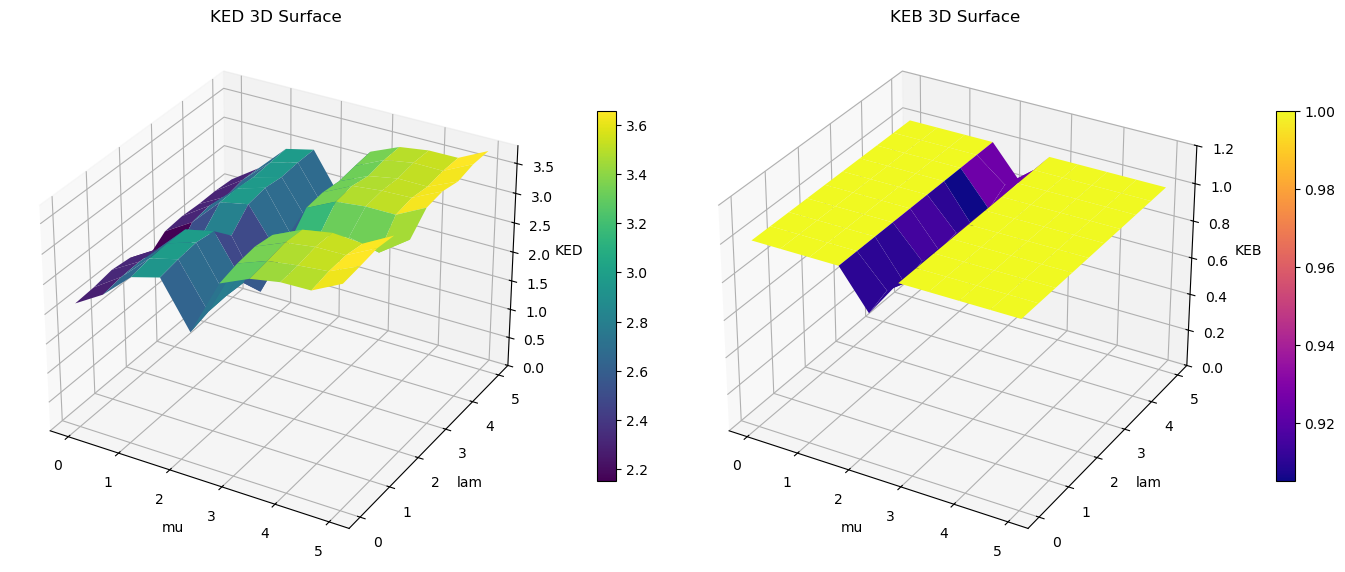

In [7]:
print("Estimating Lyapunov spectrum")
sys.lyap_scan(
	param1="mu",
	values1=np.linspace(0, 5, 10),
	param2="lam",
	values2=np.linspace(0, 5, 10),
	x0=x0,
	z0=z0,
	n=200,
	discard=100,
	save_path="./output/cml_lyapunov_scan.npz",
)
sys.plot_ked_keb("./output/cml_lyapunov_scan.npz")

### PRNG 性能分析 by NIST SP 800-22